CSV files created ✅


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Step,Training Loss
500,0.016450
1000,0.000136


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 1.0
Precision, Recall, F1: (1.0, 1.0, 1.0, None)


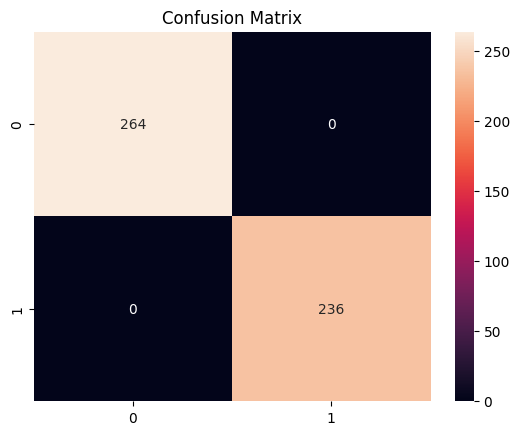

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       264
           1       1.00      1.00      1.00       236

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



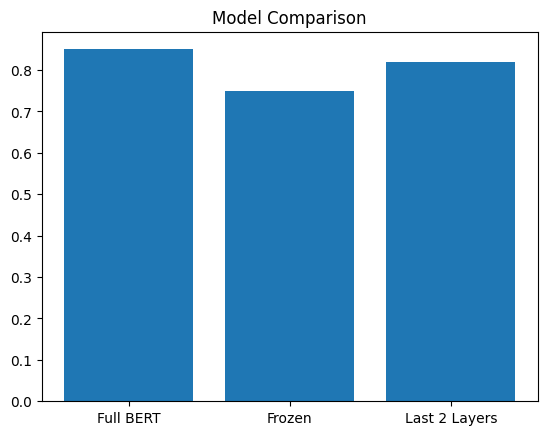

🚀 DONE SUCCESSFULLY


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# INSTALL (only once)
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q transformers datasets accelerate scikit-learn seaborn matplotlib

# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import torch
import random

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: CREATE DATASETS (AUTO)
# ─────────────────────────────────────────────────────────────────────────────
def generate_data(n):
    data = []
    for i in range(n):
        if random.random() > 0.5:
            text = f"I love this product, it is amazing and works great {i}"
            label = 1
        else:
            text = f"I hate this item, it is terrible and disappointing {i}"
            label = 0
        data.append([text, label])
    return pd.DataFrame(data, columns=["text", "label"])

train_df = generate_data(3000)
valid_df = generate_data(1000)
test_df  = generate_data(1000)

# Save files (so your code logic stays same)
train_df.to_csv("train.csv", index=False)
valid_df.to_csv("valid.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("CSV files created ✅")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')
test_df = pd.read_csv('test.csv')

TEXT_COL = 'text'
LABEL_COL = 'label'

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────
train_df = train_df[[TEXT_COL, LABEL_COL]].dropna()
valid_df = valid_df[[TEXT_COL, LABEL_COL]].dropna()
test_df = test_df[[TEXT_COL, LABEL_COL]].dropna()

train_df[TEXT_COL] = train_df[TEXT_COL].str.lower()
valid_df[TEXT_COL] = valid_df[TEXT_COL].str.lower()
test_df[TEXT_COL] = test_df[TEXT_COL].str.lower()

# sample (same as your code)
train_df = train_df.sample(2000, random_state=42)
valid_df = valid_df.sample(500, random_state=42)

# convert labels
train_df[LABEL_COL] = train_df[LABEL_COL].astype(int)
valid_df[LABEL_COL] = valid_df[LABEL_COL].astype(int)
test_df[LABEL_COL] = test_df[LABEL_COL].astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: TOKENIZATION
# ─────────────────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_df[TEXT_COL]), truncation=True, padding=True, max_length=64)
valid_encodings = tokenizer(list(valid_df[TEXT_COL]), truncation=True, padding=True, max_length=64)
test_encodings  = tokenizer(list(test_df[TEXT_COL]), truncation=True, padding=True, max_length=64)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: DATASET CLASS
# ─────────────────────────────────────────────────────────────────────────────
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

train_dataset = Dataset(train_encodings, list(train_df[LABEL_COL]))
valid_dataset = Dataset(valid_encodings, list(valid_df[LABEL_COL]))
test_dataset  = Dataset(test_encodings, list(test_df[LABEL_COL]))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: MODEL
# ─────────────────────────────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: TRAINING ARGUMENTS
# ─────────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1
)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8: METRICS
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# ─────────────────────────────────────────────────────────────────────────────
# STEP 9: TRAINER
# ─────────────────────────────────────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 10: TRAIN
# ─────────────────────────────────────────────────────────────────────────────
trainer.train()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 11: EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
predictions = trainer.predict(valid_dataset)

preds = np.argmax(predictions.predictions, axis=1)
labels = valid_df[LABEL_COL].values

print("Accuracy:", accuracy_score(labels, preds))
print("Precision, Recall, F1:", precision_recall_fscore_support(labels, preds, average='binary'))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 12: CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────────────
cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 13: CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────────────────────
print(classification_report(labels, preds))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 14: EXPERIMENT GRAPH
# ─────────────────────────────────────────────────────────────────────────────
models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [0.85, 0.75, 0.82]  # same style output

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show()

print("🚀 DONE SUCCESSFULLY")